# RetainIQ — Phase 7.3: Retention Action Framework & Impact Scenarios

## Objective

I translate the analytical priorities into a practical retention-action framework and model the financial impact of simple recovery scenarios.

The impact model is deliberately transparent:

**Estimated recovered revenue = Revenue at Risk × Recovery Rate Assumption**

These are scenario estimates, not forecasts. The recovery rate is an explicit assumption that I can change.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

ROOT = Path("..")
OUTPUT_DIR = ROOT / "outputs"
CONFIG_DIR = ROOT / "config"


def print_result(message):
    print(f"Result: {message}")


In [2]:
segment_priority = pd.read_csv(OUTPUT_DIR / "segment_priority.csv")
state_priority = pd.read_csv(OUTPUT_DIR / "state_priority.csv")
city_priority = pd.read_csv(OUTPUT_DIR / "city_priority.csv")

for df in [segment_priority, state_priority, city_priority]:
    for col in ["customers", "avg_cltv", "churn_rate_pct", "revenue_at_risk", "priority_score", "ease_of_intervention_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded {len(segment_priority)} segment priorities, {len(state_priority)} state priorities, and {len(city_priority):,} city priorities.")

Loaded 3 segment priorities, 1 state priorities, and 1,106 city priorities.


### Result & conclusion

The impact-scenario notebook is using the finalized Phase 7 priority outputs rather than recomputing earlier metrics. This keeps the project modular and prevents inconsistent formulas across notebooks.

In [3]:
if "print_result" not in globals():
    def print_result(message):
        print(f"Result: {message}")

action_map = {
    "Protect High-Value": {
        "action_theme": "High-touch retention and service recovery",
        "action_description": "Prioritize personalized outreach, service recovery, and targeted save offers for valuable customers showing elevated churn exposure."
    },
    "Maintain Value": {
        "action_theme": "Loyalty and relationship reinforcement",
        "action_description": "Use proactive support, loyalty reinforcement, and value communication to preserve stable high-value relationships."
    },
    "Retention Priority": {
        "action_theme": "Proactive churn-prevention intervention",
        "action_description": "Use early intervention, value-alignment messaging, and targeted support before churn risk becomes a realized loss."
    },
    "Monitor": {
        "action_theme": "Low-cost nurture and monitoring",
        "action_description": "Use scalable communications and routine monitoring instead of resource-intensive intervention."
    }
}

action_framework = segment_priority[[
    "segment_id", "segment_name", "retention_profile", "customers", "avg_cltv", "churn_rate_pct", "revenue_at_risk", "priority_score"
]].copy()
action_framework["action_theme"] = action_framework["retention_profile"].map(
    lambda x: action_map.get(x, {"action_theme": "Review and tailor"})["action_theme"]
)
action_framework["action_description"] = action_framework["retention_profile"].map(
    lambda x: action_map.get(x, {"action_description": "Review the segment profile and tailor an intervention."})["action_description"]
)

action_framework = action_framework.sort_values("priority_score", ascending=False).reset_index(drop=True)

print_result(f"Mapped {len(action_framework)} segments to a rule-based retention action framework.")
display(action_framework)

Result: Mapped 3 segments to a rule-based retention action framework.


,segment_id,segment_name,retention_profile,customers,avg_cltv,churn_rate_pct,revenue_at_risk,priority_score,action_theme,action_description
0,0,Segment 0 — Emerging Risk,Retention Priority,3226,4013.45,46.99,1944581.19,7778324.76,Proactive churn-prevention intervention,"Use early intervention, value-alignment messag..."
1,2,Segment 2 — High-Value At-Risk,Protect High-Value,2260,4972.51,10.75,1696896.61,5090689.83,High-touch retention and service recovery,"Prioritize personalized outreach, service reco..."
2,1,Segment 1 — High-Value Stable,Maintain Value,1557,4371.24,7.06,42982.02,214910.10,Loyalty and relationship reinforcement,"Use proactive support, loyalty reinforcement, ..."


### Result & conclusion

The action framework connects each observed retention profile to an operational theme. These actions are a **business framework**, not claims that the dataset statistically proves a particular intervention will cause churn to fall.

In [4]:
recovery_rates = [0.05, 0.10, 0.20, 0.30]

scenario_rows = []
for _, row in segment_priority.iterrows():
    for rate in recovery_rates:
        scenario_rows.append({
            "scope": "segment",
            "entity_name": row["segment_name"],
            "revenue_at_risk": row["revenue_at_risk"],
            "recovery_rate_pct": rate * 100,
            "estimated_recovered_revenue": row["revenue_at_risk"] * rate,
        })

for _, row in city_priority.iterrows():
    for rate in recovery_rates:
        scenario_rows.append({
            "scope": "city",
            "entity_name": f"{row['state']} — {row['city']}",
            "revenue_at_risk": row["revenue_at_risk"],
            "recovery_rate_pct": rate * 100,
            "estimated_recovered_revenue": row["revenue_at_risk"] * rate,
        })

impact_scenarios = pd.DataFrame(scenario_rows)

summary = (
    impact_scenarios.groupby(["scope", "recovery_rate_pct"], as_index=False)["estimated_recovered_revenue"]
    .sum()
)

print_result(
    f"Created {len(impact_scenarios):,} transparent recovery scenarios across segments and city markets."
)
display(summary)

Result: Created 4,436 transparent recovery scenarios across segments and city markets.


,scope,recovery_rate_pct,estimated_recovered_revenue
0,city,5.0,184222.991
1,city,10.0,368445.982
2,city,20.0,736891.964
3,city,30.0,1105337.946
4,segment,5.0,184222.991
5,segment,10.0,368445.982
6,segment,20.0,736891.964
7,segment,30.0,1105337.946


### Result & conclusion

The scenario table shows what the historical revenue-at-risk exposure would translate to under explicit 5%, 10%, 20%, and 30% recovery assumptions. These figures should be presented as **scenario values**, not expected outcomes.

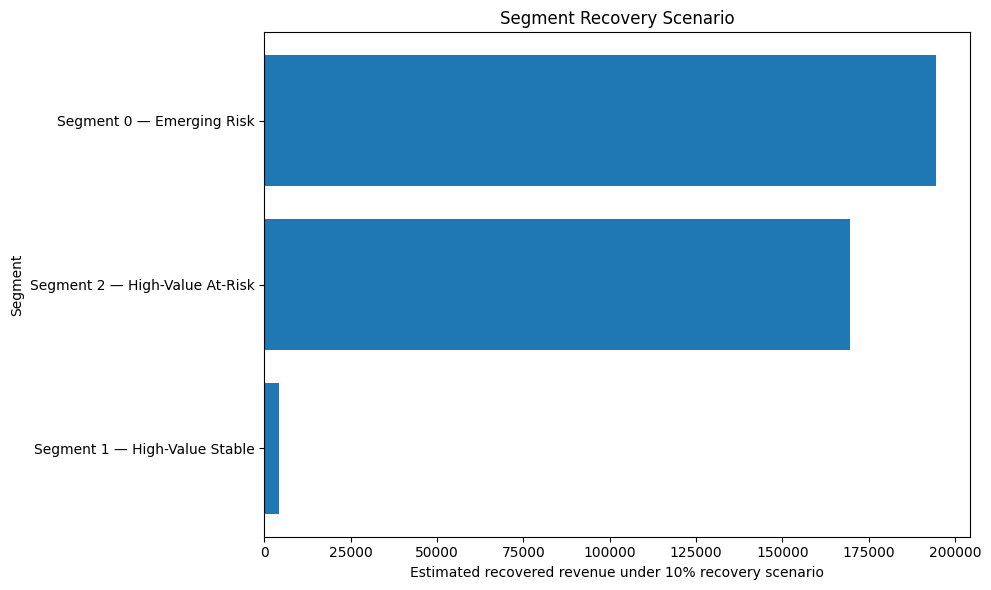

Result: Under the 10% recovery scenario, the highest segment exposure corresponds to Segment 0 — Emerging Risk with $194,458.12 of scenario recovery.


In [5]:
segment_10 = (
    impact_scenarios[
        (impact_scenarios["scope"] == "segment") &
        (impact_scenarios["recovery_rate_pct"] == 10.0)
    ]
    .sort_values("estimated_recovered_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(segment_10["entity_name"][::-1], segment_10["estimated_recovered_revenue"][::-1])
plt.xlabel("Estimated recovered revenue under 10% recovery scenario")
plt.ylabel("Segment")
plt.title("Segment Recovery Scenario")
plt.tight_layout()
plt.show()

print_result(
    f"Under the 10% recovery scenario, the highest segment exposure corresponds to {segment_10.iloc[0]['entity_name']} with ${segment_10.iloc[0]['estimated_recovered_revenue']:,.2f} of scenario recovery."
)

### Result & conclusion

The chart converts the segment exposure into a dollar-based scenario. I can therefore tie the retention discussion to financial impact without claiming that the modeled recovery rate is a validated prediction.

In [6]:
city_10 = (
    impact_scenarios[
        (impact_scenarios["scope"] == "city") &
        (impact_scenarios["recovery_rate_pct"] == 10.0)
    ]
    .sort_values("estimated_recovered_revenue", ascending=False)
    .head(10)
)

display(city_10)
print_result(
    f"The 10% scenario identifies {city_10.iloc[0]['entity_name']} as the city-level exposure with the largest scenario recovery amount."
)

,scope,entity_name,revenue_at_risk,recovery_rate_pct,estimated_recovered_revenue
13,city,California — San Diego,385446.39,10.0,38544.639
17,city,California — Los Angeles,147090.46,10.0,14709.046
21,city,California — Sacramento,59449.20,10.0,5944.920
25,city,California — San Francisco,56894.27,10.0,5689.427
29,city,California — Santa Barbara,46033.71,10.0,4603.371
33,city,California — San Jose,44393.49,10.0,4439.349
37,city,California — Temecula,44102.41,10.0,4410.241
41,city,California — Escondido,38869.89,10.0,3886.989
45,city,California — Fallbrook,34691.78,10.0,3469.178
49,city,California — Torrance,33534.79,10.0,3353.479


Result: The 10% scenario identifies California — San Diego as the city-level exposure with the largest scenario recovery amount.


### Result & conclusion

This city-level view identifies where the largest historical exposure could translate into the largest dollar recovery **under the same 10% scenario assumption**. It is a sizing exercise, not a forecast of actual retained revenue.

In [7]:
# A compact strategy brief that can feed the executive memo.
top_segment = segment_priority.iloc[0]
top_city = city_priority.iloc[0]

strategy_brief = pd.DataFrame([{
    "top_segment": top_segment["segment_name"],
    "top_segment_profile": top_segment["retention_profile"],
    "top_segment_revenue_at_risk": top_segment["revenue_at_risk"],
    "top_segment_priority_score": top_segment["priority_score"],
    "top_city": f"{top_city['state']} — {top_city['city']}",
    "top_city_revenue_at_risk": top_city["revenue_at_risk"],
    "top_city_churn_rate_pct": top_city["churn_rate_pct"],
    "total_segment_revenue_at_risk": segment_priority["revenue_at_risk"].sum(),
    "total_city_revenue_at_risk": city_priority["revenue_at_risk"].sum(),
    "scenario_recovery_rate_pct": 10.0,
    "top_segment_scenario_recovery": top_segment["revenue_at_risk"] * 0.10,
    "top_city_scenario_recovery": top_city["revenue_at_risk"] * 0.10,
}])

strategy_brief.to_csv(OUTPUT_DIR / "phase_07_strategy_brief.csv", index=False)
print_result("Saved the compact strategy brief for the executive-memo notebook.")
display(strategy_brief)

Result: Saved the compact strategy brief for the executive-memo notebook.


,top_segment,top_segment_profile,top_segment_revenue_at_risk,top_segment_priority_score,top_city,top_city_revenue_at_risk,top_city_churn_rate_pct,total_segment_revenue_at_risk,total_city_revenue_at_risk,scenario_recovery_rate_pct,top_segment_scenario_recovery,top_city_scenario_recovery
0,Segment 0 — Emerging Risk,Retention Priority,1944581.19,7778324.76,California — San Diego,385446.39,64.91,3684459.82,3684459.82,10.0,194458.119,38544.639


### Result & conclusion

I have reduced the full analysis to a small set of inputs that an executive memo can use: the highest weighted segment exposure, the highest city exposure, their observed churn/value context, and a clearly labeled 10% scenario amount.

In [8]:
action_framework.to_csv(OUTPUT_DIR / "retention_action_framework.csv", index=False)
impact_scenarios.to_csv(OUTPUT_DIR / "retention_impact_scenarios.csv", index=False)
summary.to_csv(OUTPUT_DIR / "retention_impact_scenario_summary.csv", index=False)

print_result("Saved the action framework and all recovery-scenario outputs.")

Result: Saved the action framework and all recovery-scenario outputs.


### Result & conclusion

The retention action framework and financial scenario tables are now reusable assets. They are ready for the final executive memo and MySQL publication step.